In [196]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [197]:
df = pd.read_csv(r"/Users/manafosman/Documents/QuitosAi docs/users (2).csv",parse_dates=["created_at"])
df_pay = pd.read_csv(r"/Users/manafosman/Downloads/payments.csv")

In [199]:
df_pay.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          9 non-null      int64 
 1   user_id     9 non-null      int64 
 2   reference   9 non-null      object
 3   plan        9 non-null      object
 4   amount      9 non-null      int64 
 5   created_at  9 non-null      object
 6   provider    9 non-null      object
dtypes: int64(3), object(4)
memory usage: 632.0+ bytes


In [201]:
df.describe()

,id,password_hash,created_at,paystack_customer_code,paystack_subscription_code,project_credits
count,671.000000,0.0,671,0.0,0.0,671.000000
mean,336.998510,NaN,2026-05-26 15:04:27.732495360,NaN,NaN,0.001490
min,1.000000,NaN,2026-02-11 07:03:10.422266,NaN,NaN,0.000000
25%,169.500000,NaN,2026-04-30 20:25:42.042937600,NaN,NaN,0.000000
50%,337.000000,NaN,2026-05-21 06:50:40.918234112,NaN,NaN,0.000000
75%,504.500000,NaN,2026-06-20 12:07:25.377224448,NaN,NaN,0.000000
max,672.000000,NaN,2026-08-17 20:03:21.105088,NaN,NaN,1.000000
std,193.847882,NaN,NaN,NaN,NaN,0.038605


In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   id                          671 non-null    int64         
 1   full_name                   671 non-null    object        
 2   email                       671 non-null    object        
 3   password_hash               0 non-null      float64       
 4   role                        533 non-null    object        
 5   university                  435 non-null    object        
 6   field_of_study              468 non-null    object        
 7   citation_style              671 non-null    object        
 8   ai_autonomy                 671 non-null    object        
 9   created_at                  671 non-null    datetime64[ns]
 10  google_id                   670 non-null    object        
 11  image                       660 non-null    object        

In [203]:
pd.to_datetime(df["created_at"])

0     2026-02-11 07:03:10.422266
1     2026-02-11 17:59:11.345570
2     2026-03-05 18:42:21.787424
3     2026-03-07 16:34:40.427401
4     2026-03-07 18:22:51.502383
                 ...            
666   2026-08-15 08:32:32.959170
667   2026-08-15 11:25:46.515155
668   2026-08-16 23:51:16.098557
669   2026-08-17 08:35:07.834493
670   2026-08-17 20:03:21.105088
Name: created_at, Length: 671, dtype: datetime64[ns]

In [204]:
df["signup_month"] = df["created_at"].dt.to_period("M")

In [205]:
monthly_signups = df.groupby("signup_month").size().reset_index(name="new_users")

In [206]:
monthly_signups["signup_month"] = monthly_signups["signup_month"].dt.to_timestamp()

In [207]:
monthly_signups

,signup_month,new_users
0,2026-02-01,2
1,2026-03-01,57
2,2026-04-01,110
3,2026-05-01,267
4,2026-06-01,95
5,2026-07-01,84
6,2026-08-01,56


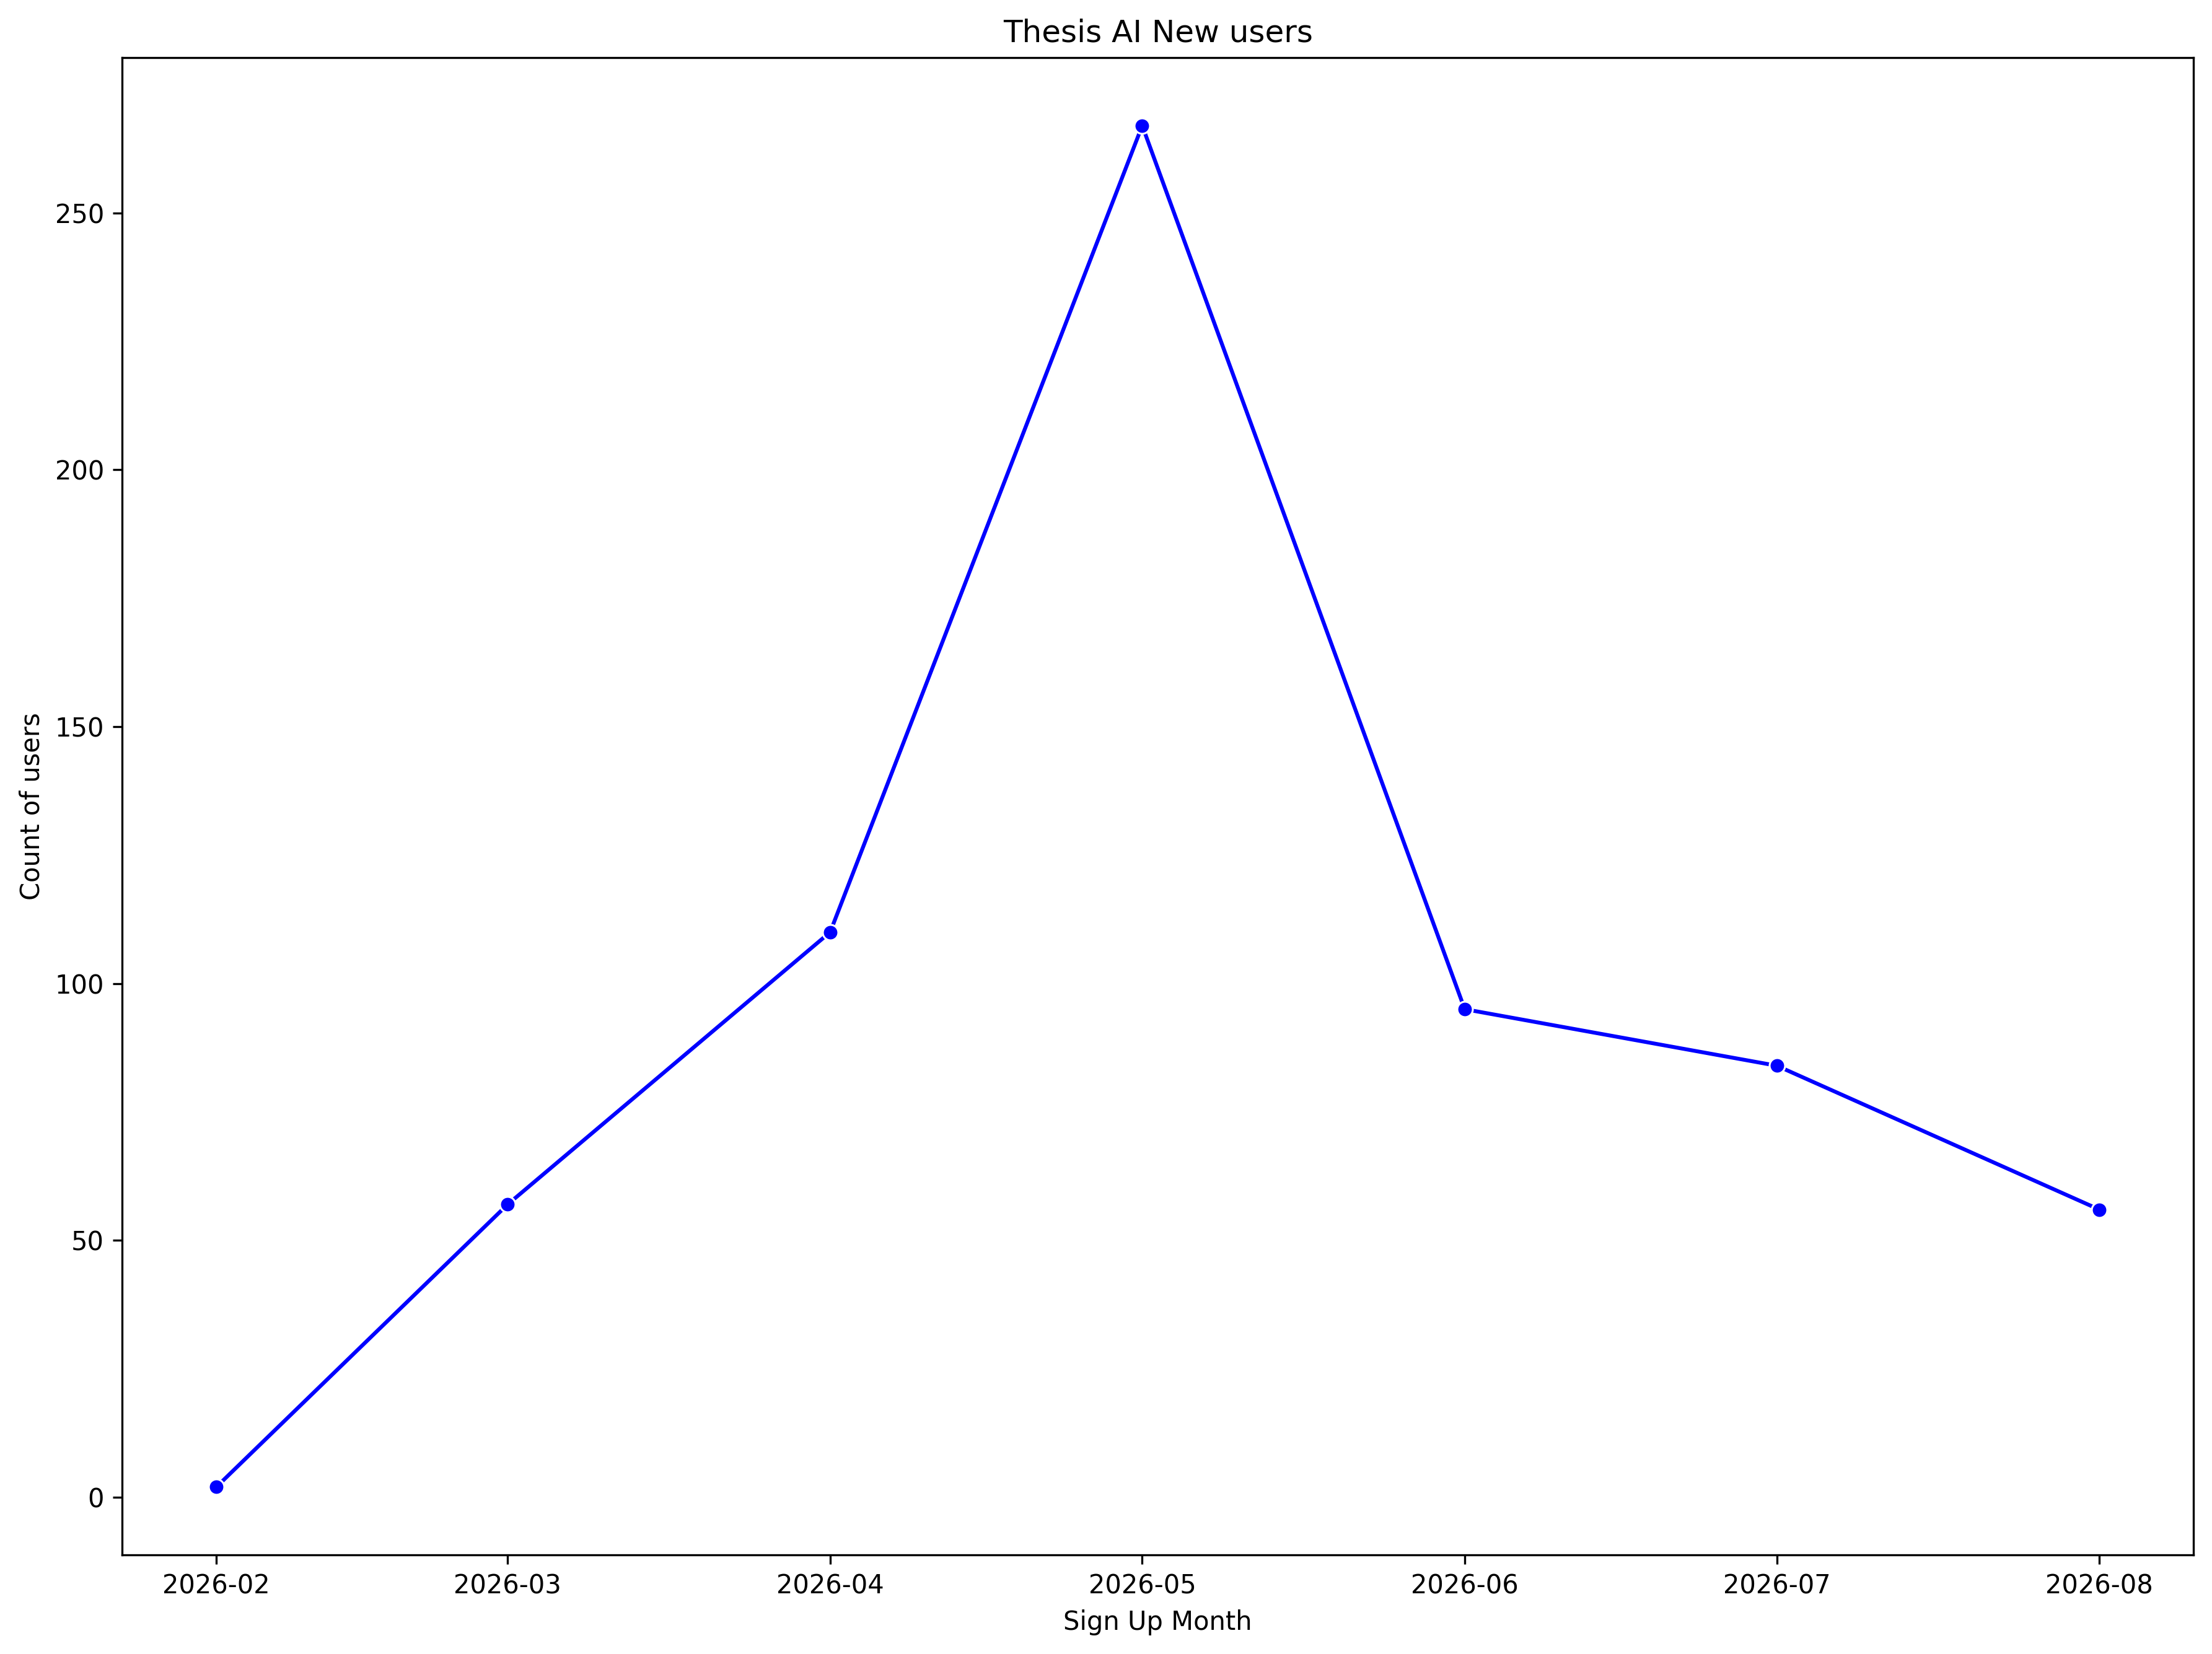

In [208]:
plt.figure(figsize=(12,9),dpi=300)
sns.lineplot(data=monthly_signups,x="signup_month",y="new_users",color="blue",marker="o")
plt.title("Thesis AI New users")
plt.xlabel("Sign Up Month")
plt.ylabel("Count of users")
plt.tight_layout()
plt.show()

In [209]:
monthly_signups["cumulative_users"] = monthly_signups["new_users"].cumsum()
monthly_signups

,signup_month,new_users,cumulative_users
0,2026-02-01,2,2
1,2026-03-01,57,59
2,2026-04-01,110,169
3,2026-05-01,267,436
4,2026-06-01,95,531
5,2026-07-01,84,615
6,2026-08-01,56,671


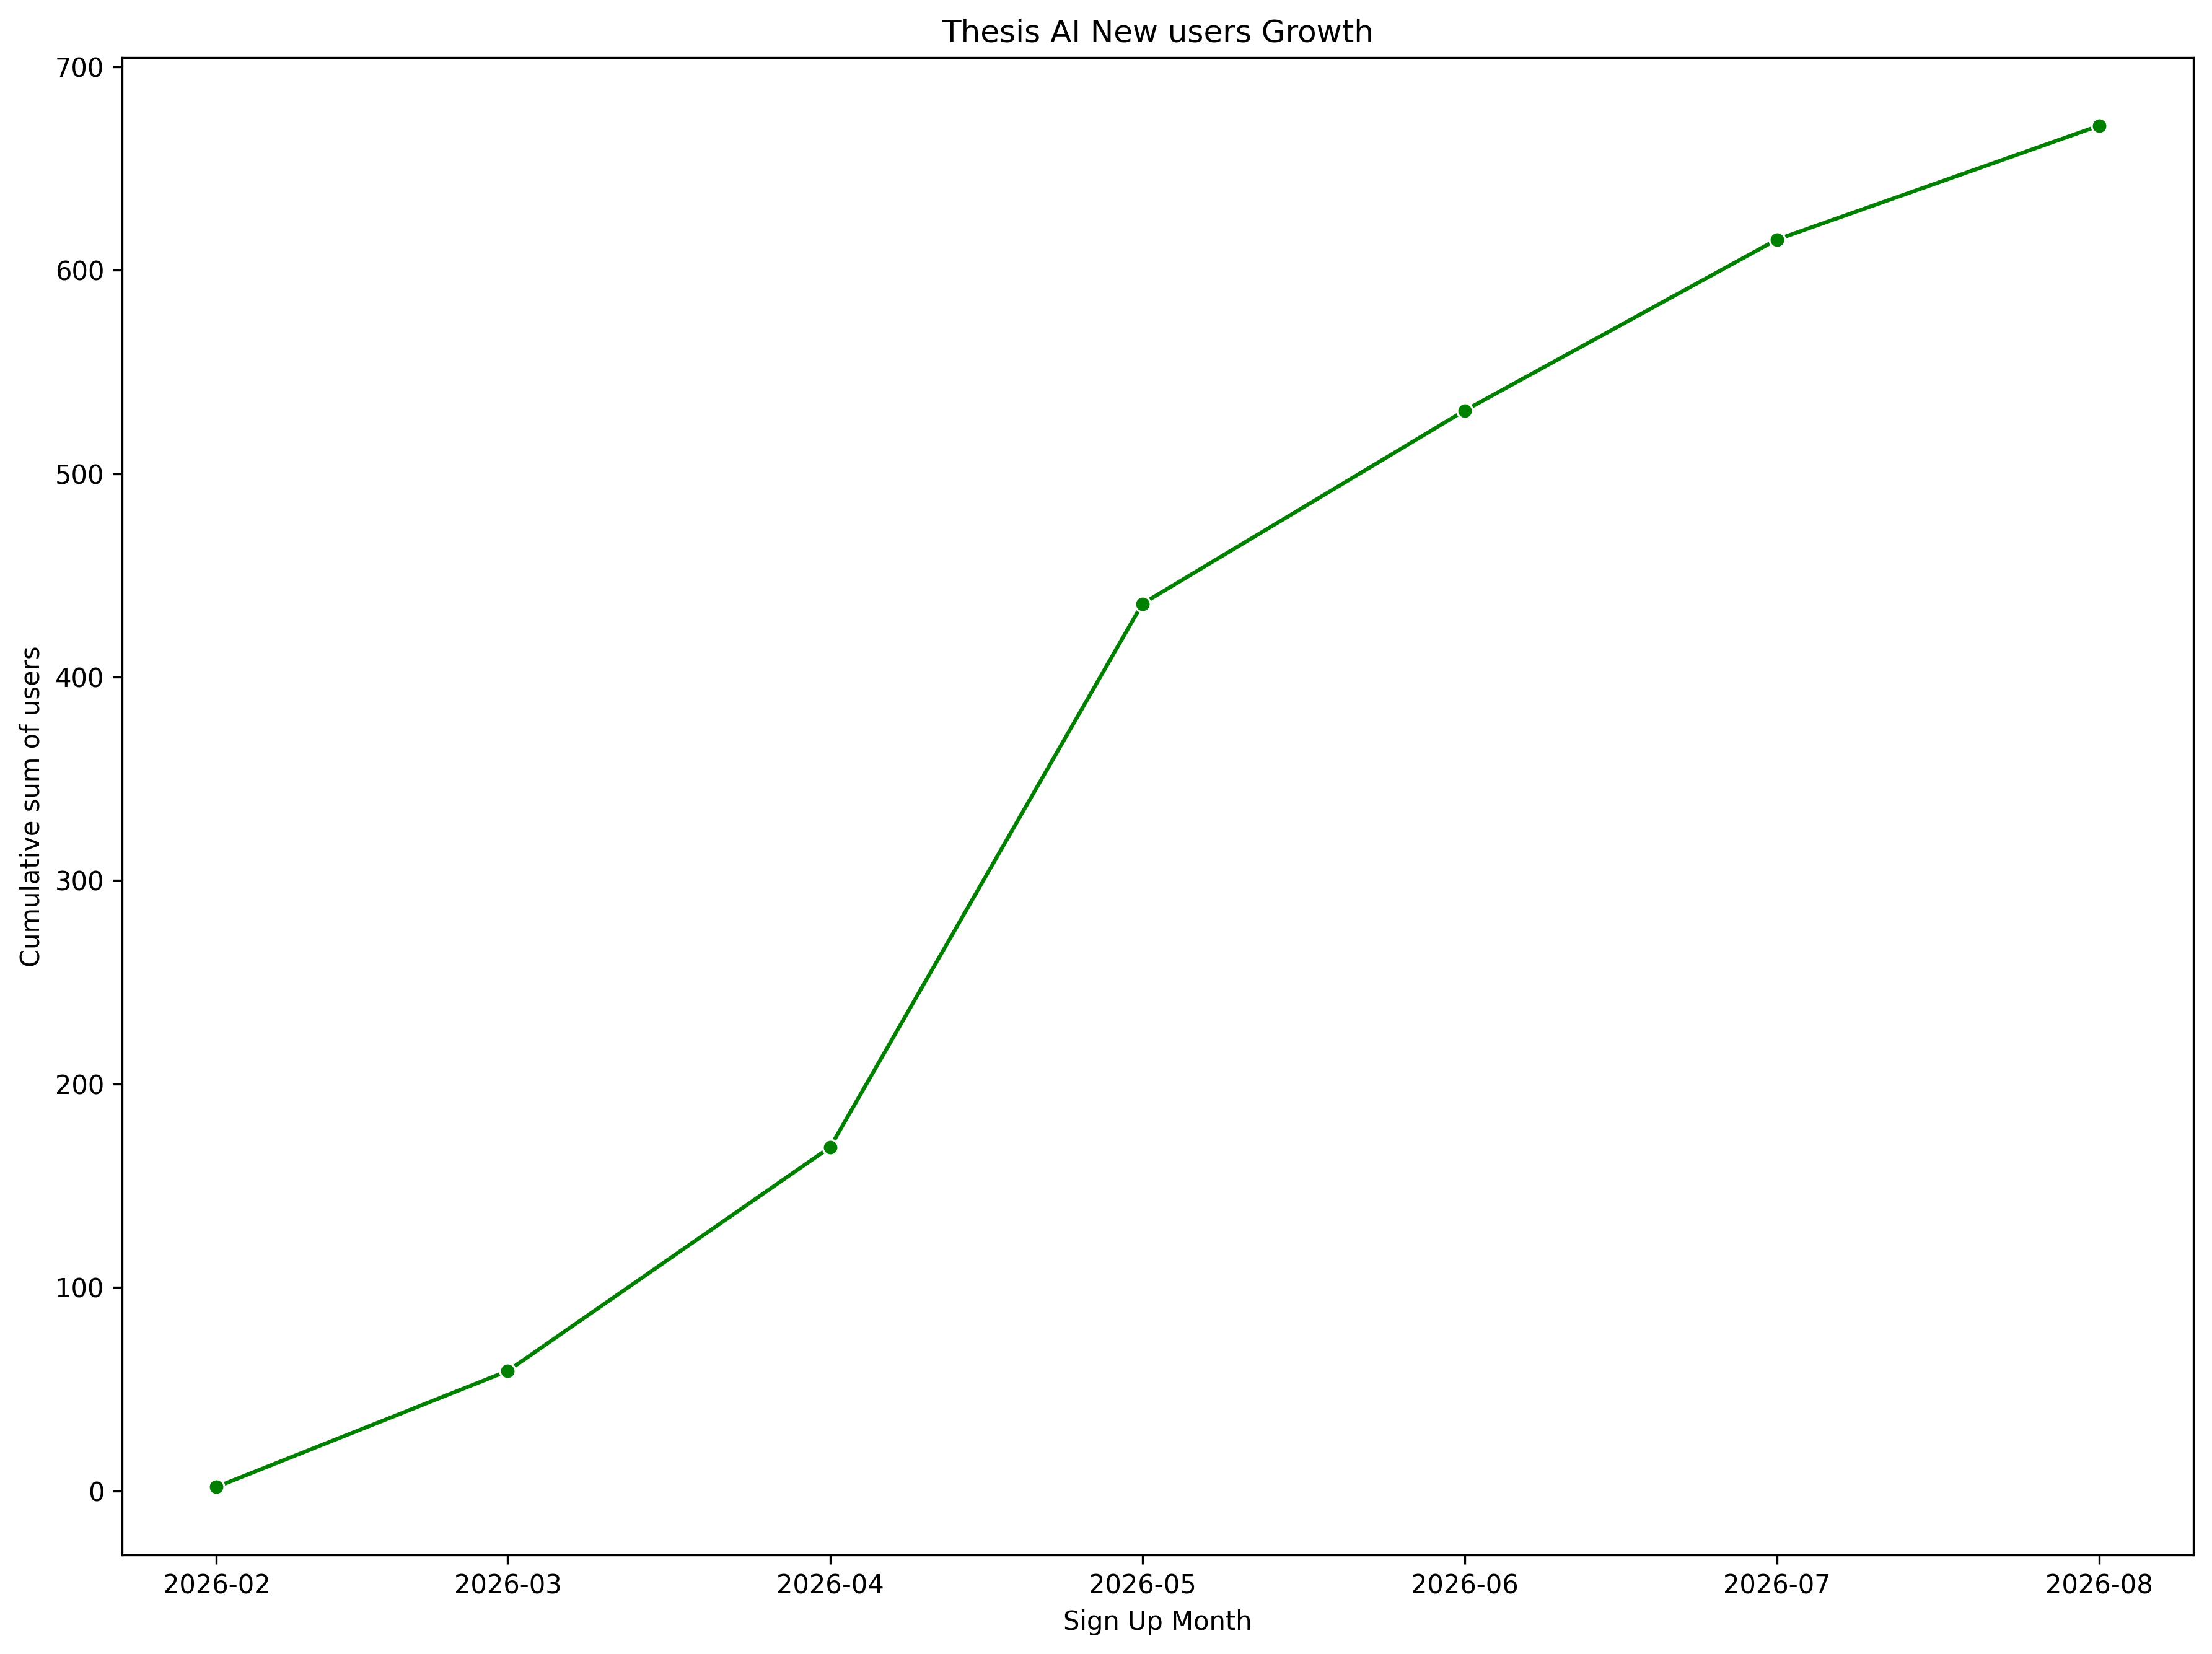

In [210]:
plt.figure(figsize=(12,9),dpi=300)
sns.lineplot(data=monthly_signups,x="signup_month",y="cumulative_users",color="green",marker="o")
plt.title("Thesis AI New users Growth")
plt.xlabel("Sign Up Month")
plt.ylabel("Cumulative sum of users")
plt.tight_layout()
plt.show()

In [211]:
df["plan"].value_counts()

plan
free             668
masters            2
undergraduate      1
Name: count, dtype: int64

In [212]:
df["payment_status"] = df["id"].isin(df_pay["user_id"]).map({True:"paid",False:"free"})

In [213]:
df[["id","full_name","plan","payment_status"]].head(10)

,id,full_name,plan,payment_status
0,1,Dr. Kwame Asante,undergraduate,free
1,3,Daniel Boadzie,masters,paid
2,4,Daniel Boadzie,free,free
3,5,Kennedy Owusu,free,free
4,6,Wisdom Kwesi Nyama,free,free
5,7,Michael Kumi,free,free
6,8,Ebenezer Ohenebeng,free,free
7,9,Eric Akatsi,free,free
8,10,Deborah Ama Owusua,free,free
9,11,nkds,free,free


In [214]:
df["payment_status"].value_counts()

payment_status
free    663
paid      8
Name: count, dtype: int64

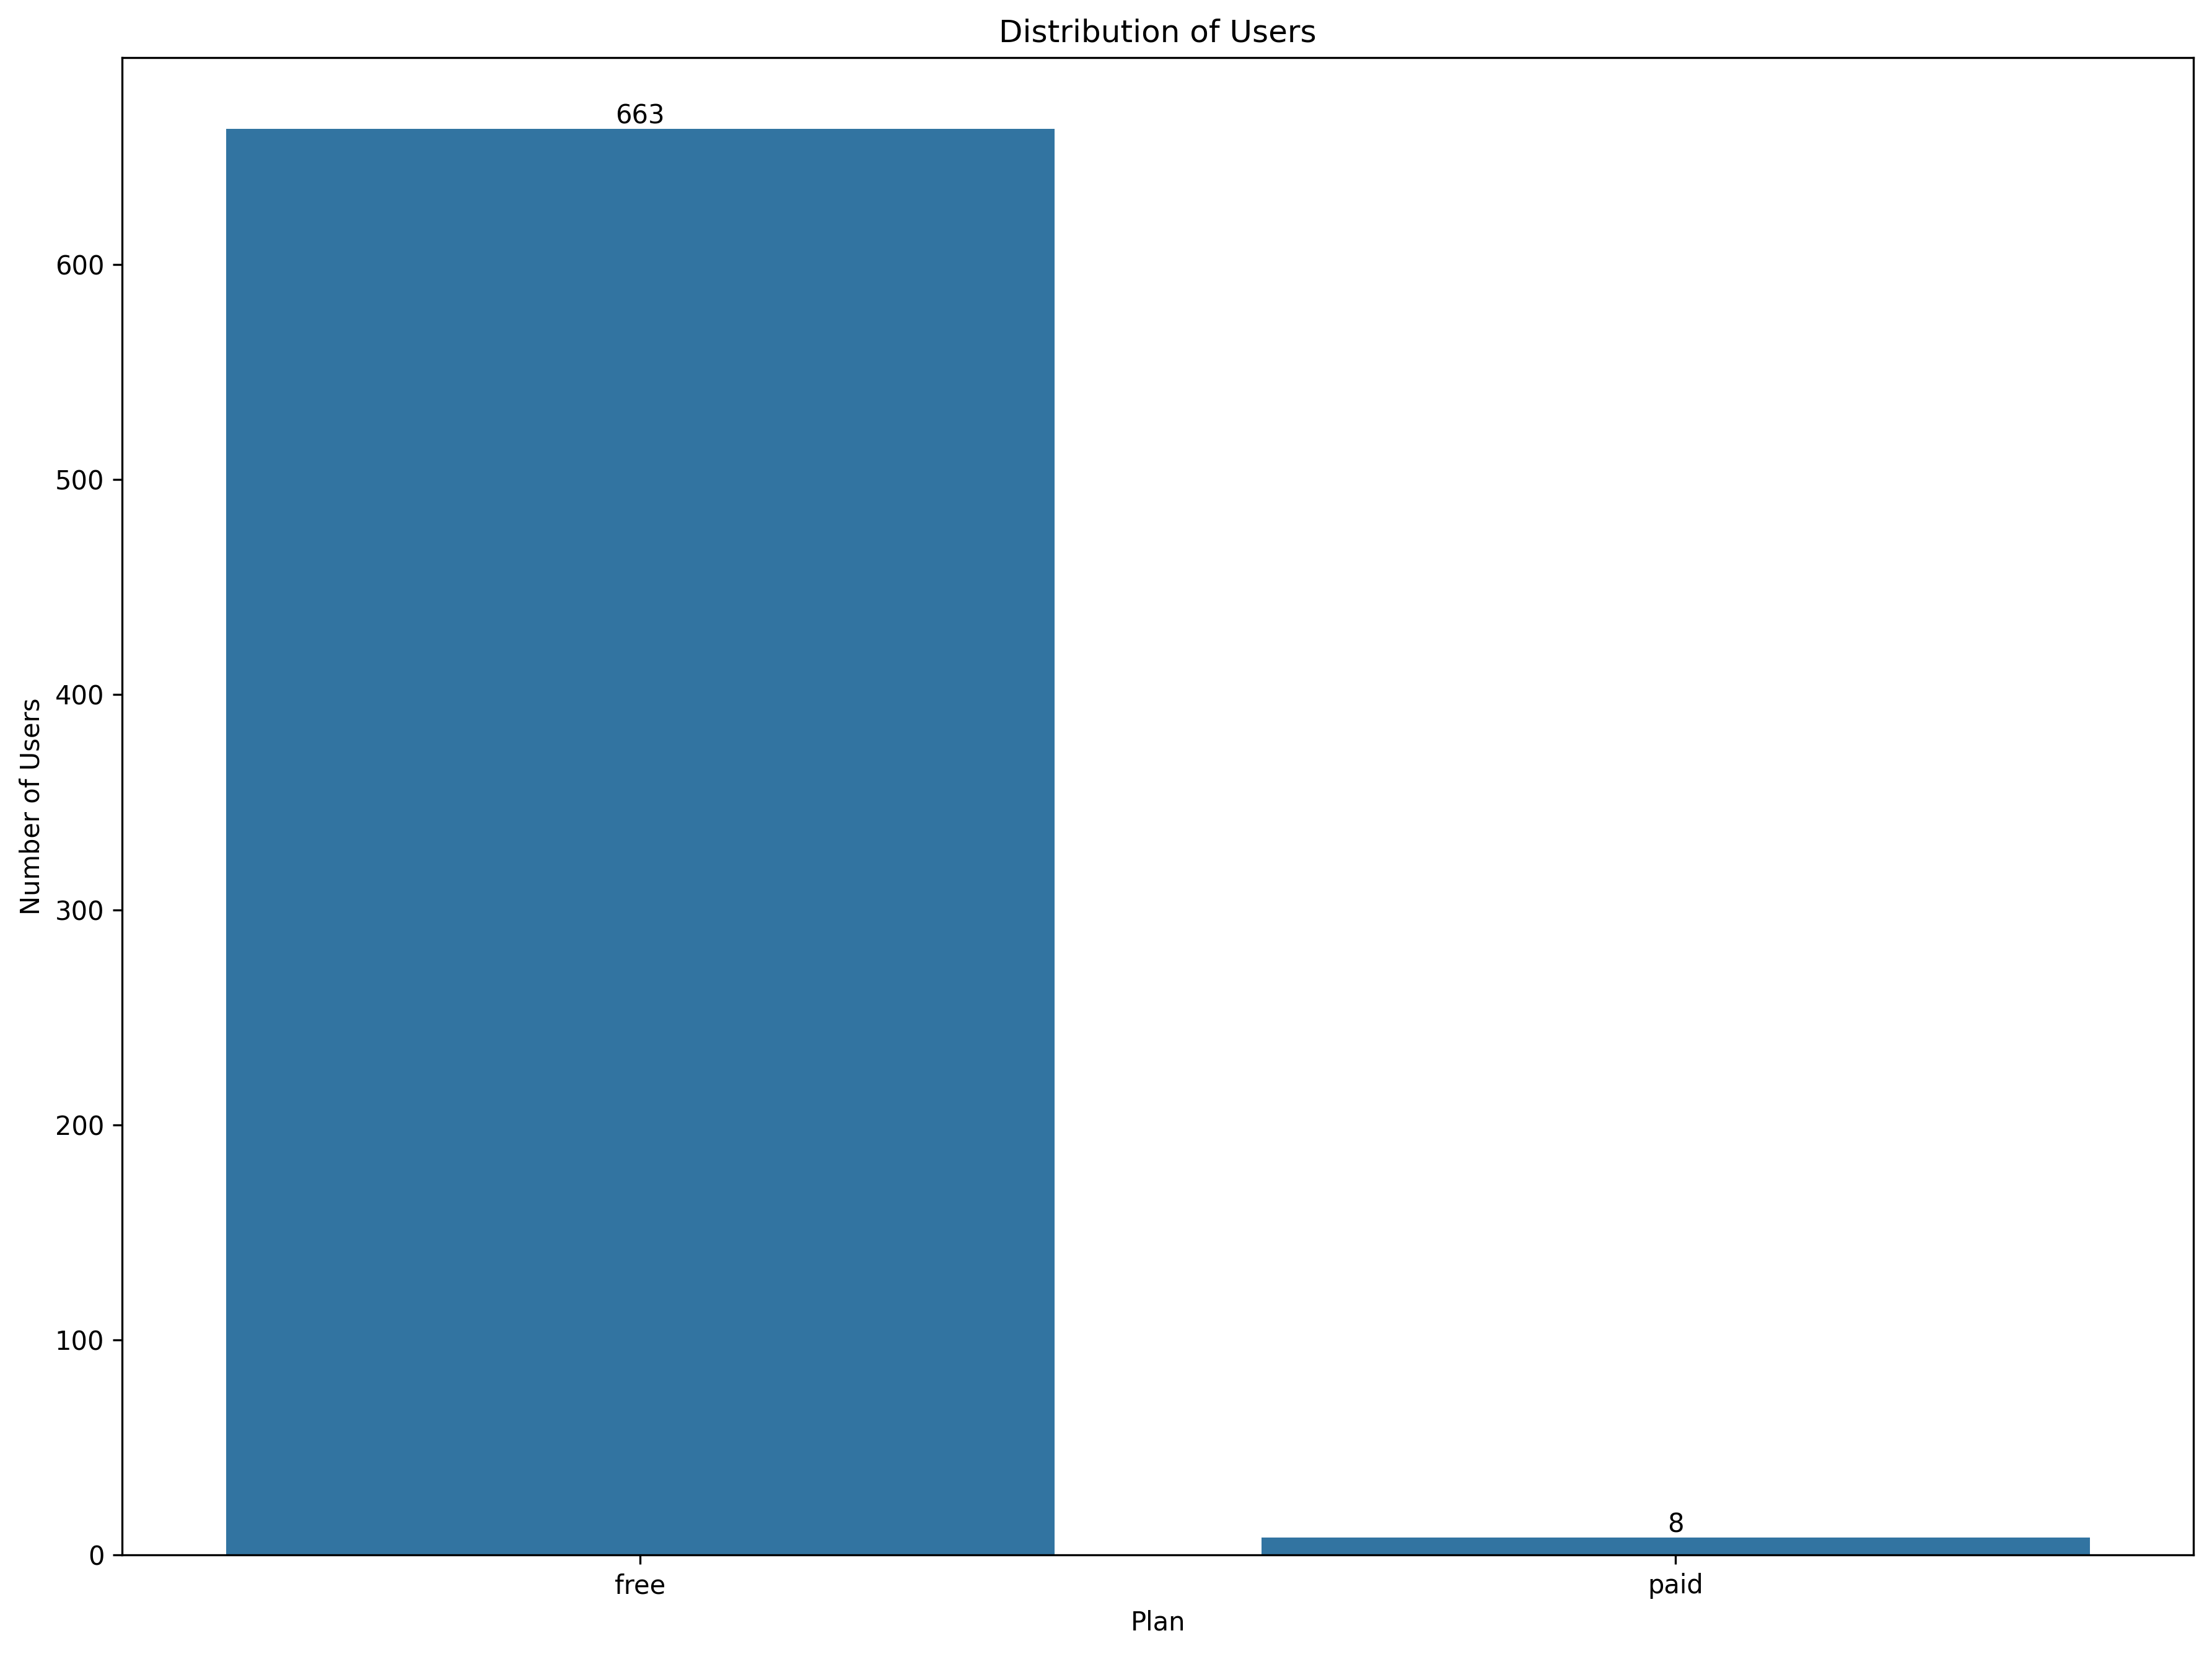

In [215]:
plt.figure(figsize=(12,9),dpi=300)
ax = sns.countplot(data= df ,x="payment_status")
plt.title("Distribution of Users")
plt.xlabel("Plan")
plt.ylabel("Number of Users")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [ ]:
df

subscription_status
inactive    669
active        2
Name: count, dtype: int64

In [217]:
#UNIVERSITIES
df["university"].value_counts().head(10) 

university
University of Ghana             8
KNUST                           3
Institut Teknologi Bandung      3
Tribhuvan University            3
UNIVERSITAS WARMADEWA           2
Oklahoma State University       2
-                               2
University of the Free State    2
Anna university                 2
university of delhi             2
Name: count, dtype: int64

In [218]:
university_users = (df.groupby("university").size().sort_values(ascending=False).head(9))
university_users

university
University of Ghana           8
Institut Teknologi Bandung    3
Tribhuvan University          3
KNUST                         3
-                             2
Oklahoma State University     2
iehe                          2
Anna university               2
university of delhi           2
dtype: int64

In [236]:
top_10 =df["field_of_study"].value_counts().head(10)

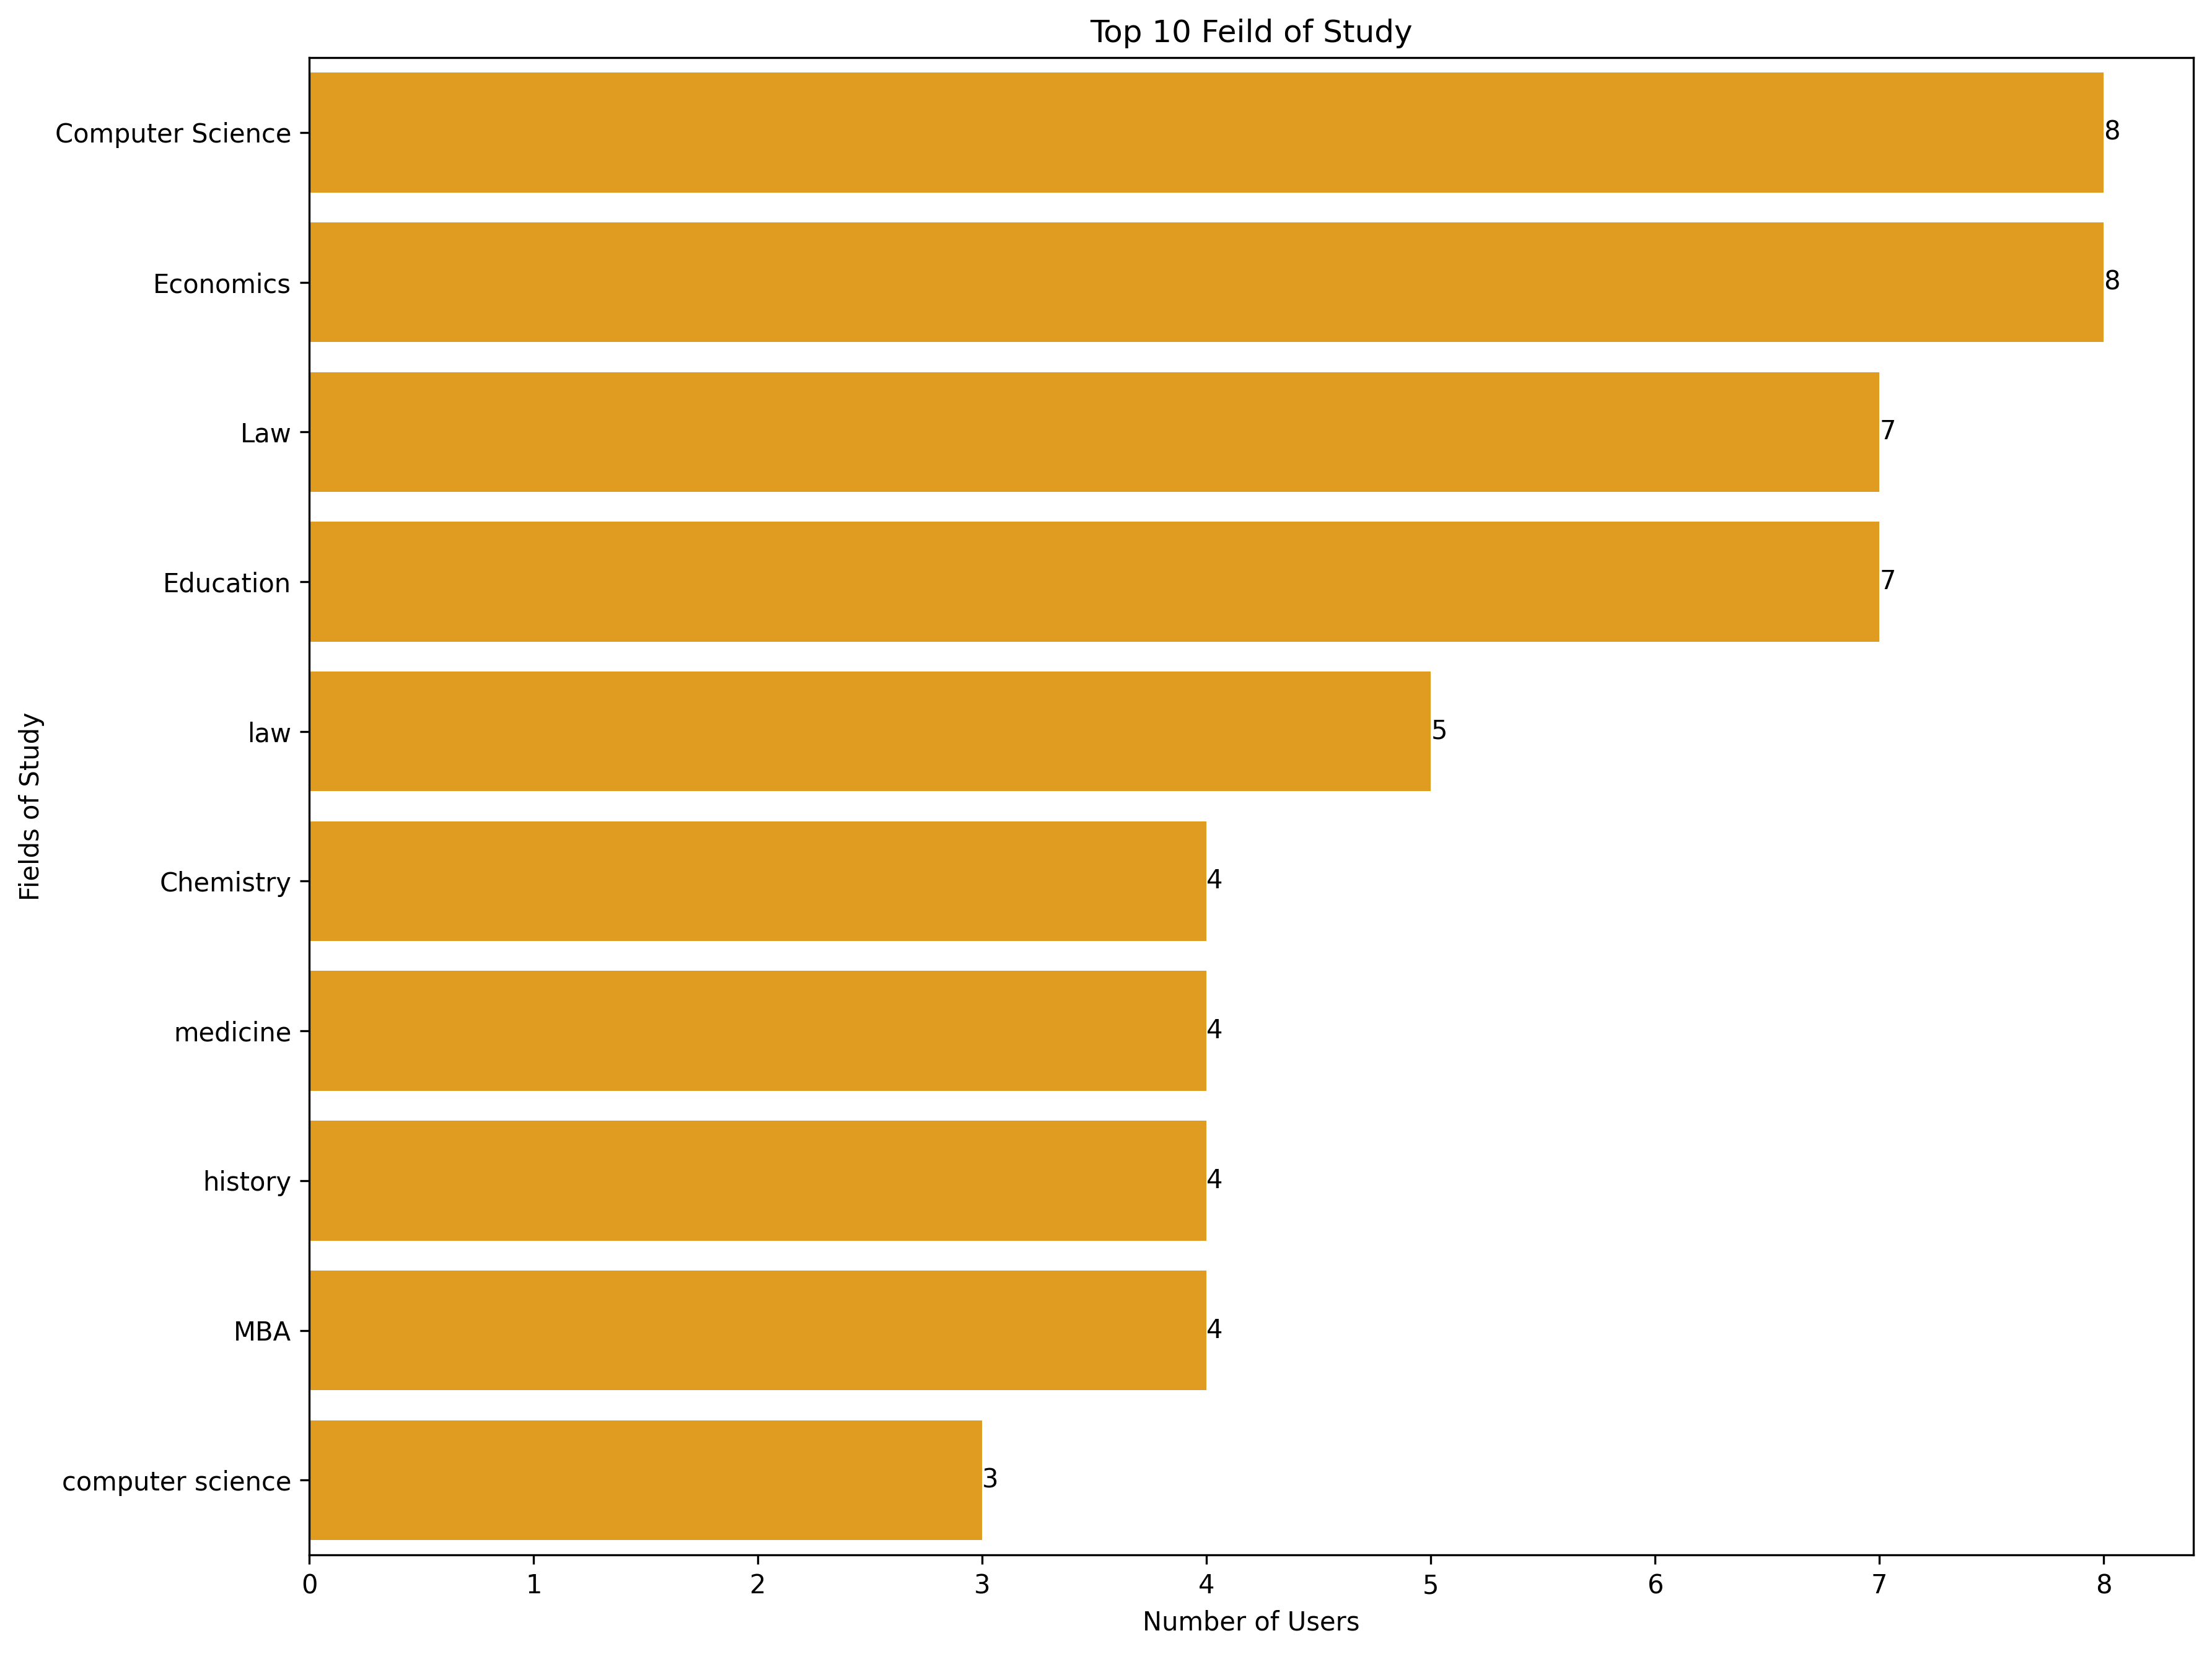

In [246]:
plt.figure(figsize=(12,9),dpi=300)
ax = sns.barplot(x= top_10.values,y=top_10.index,color="orange")
plt.title("Top 10 Feild of Study")
plt.xlabel("Number of Users")
plt.ylabel("Fields of Study")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [248]:
df["citation_style"].value_counts()
citation_share = (
    df["citation_style"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)
citation_share

citation_style
APA 7      74.7
Harvard    12.8
IEEE        7.3
Chicago     2.8
MLA 9       2.4
Name: proportion, dtype: float64

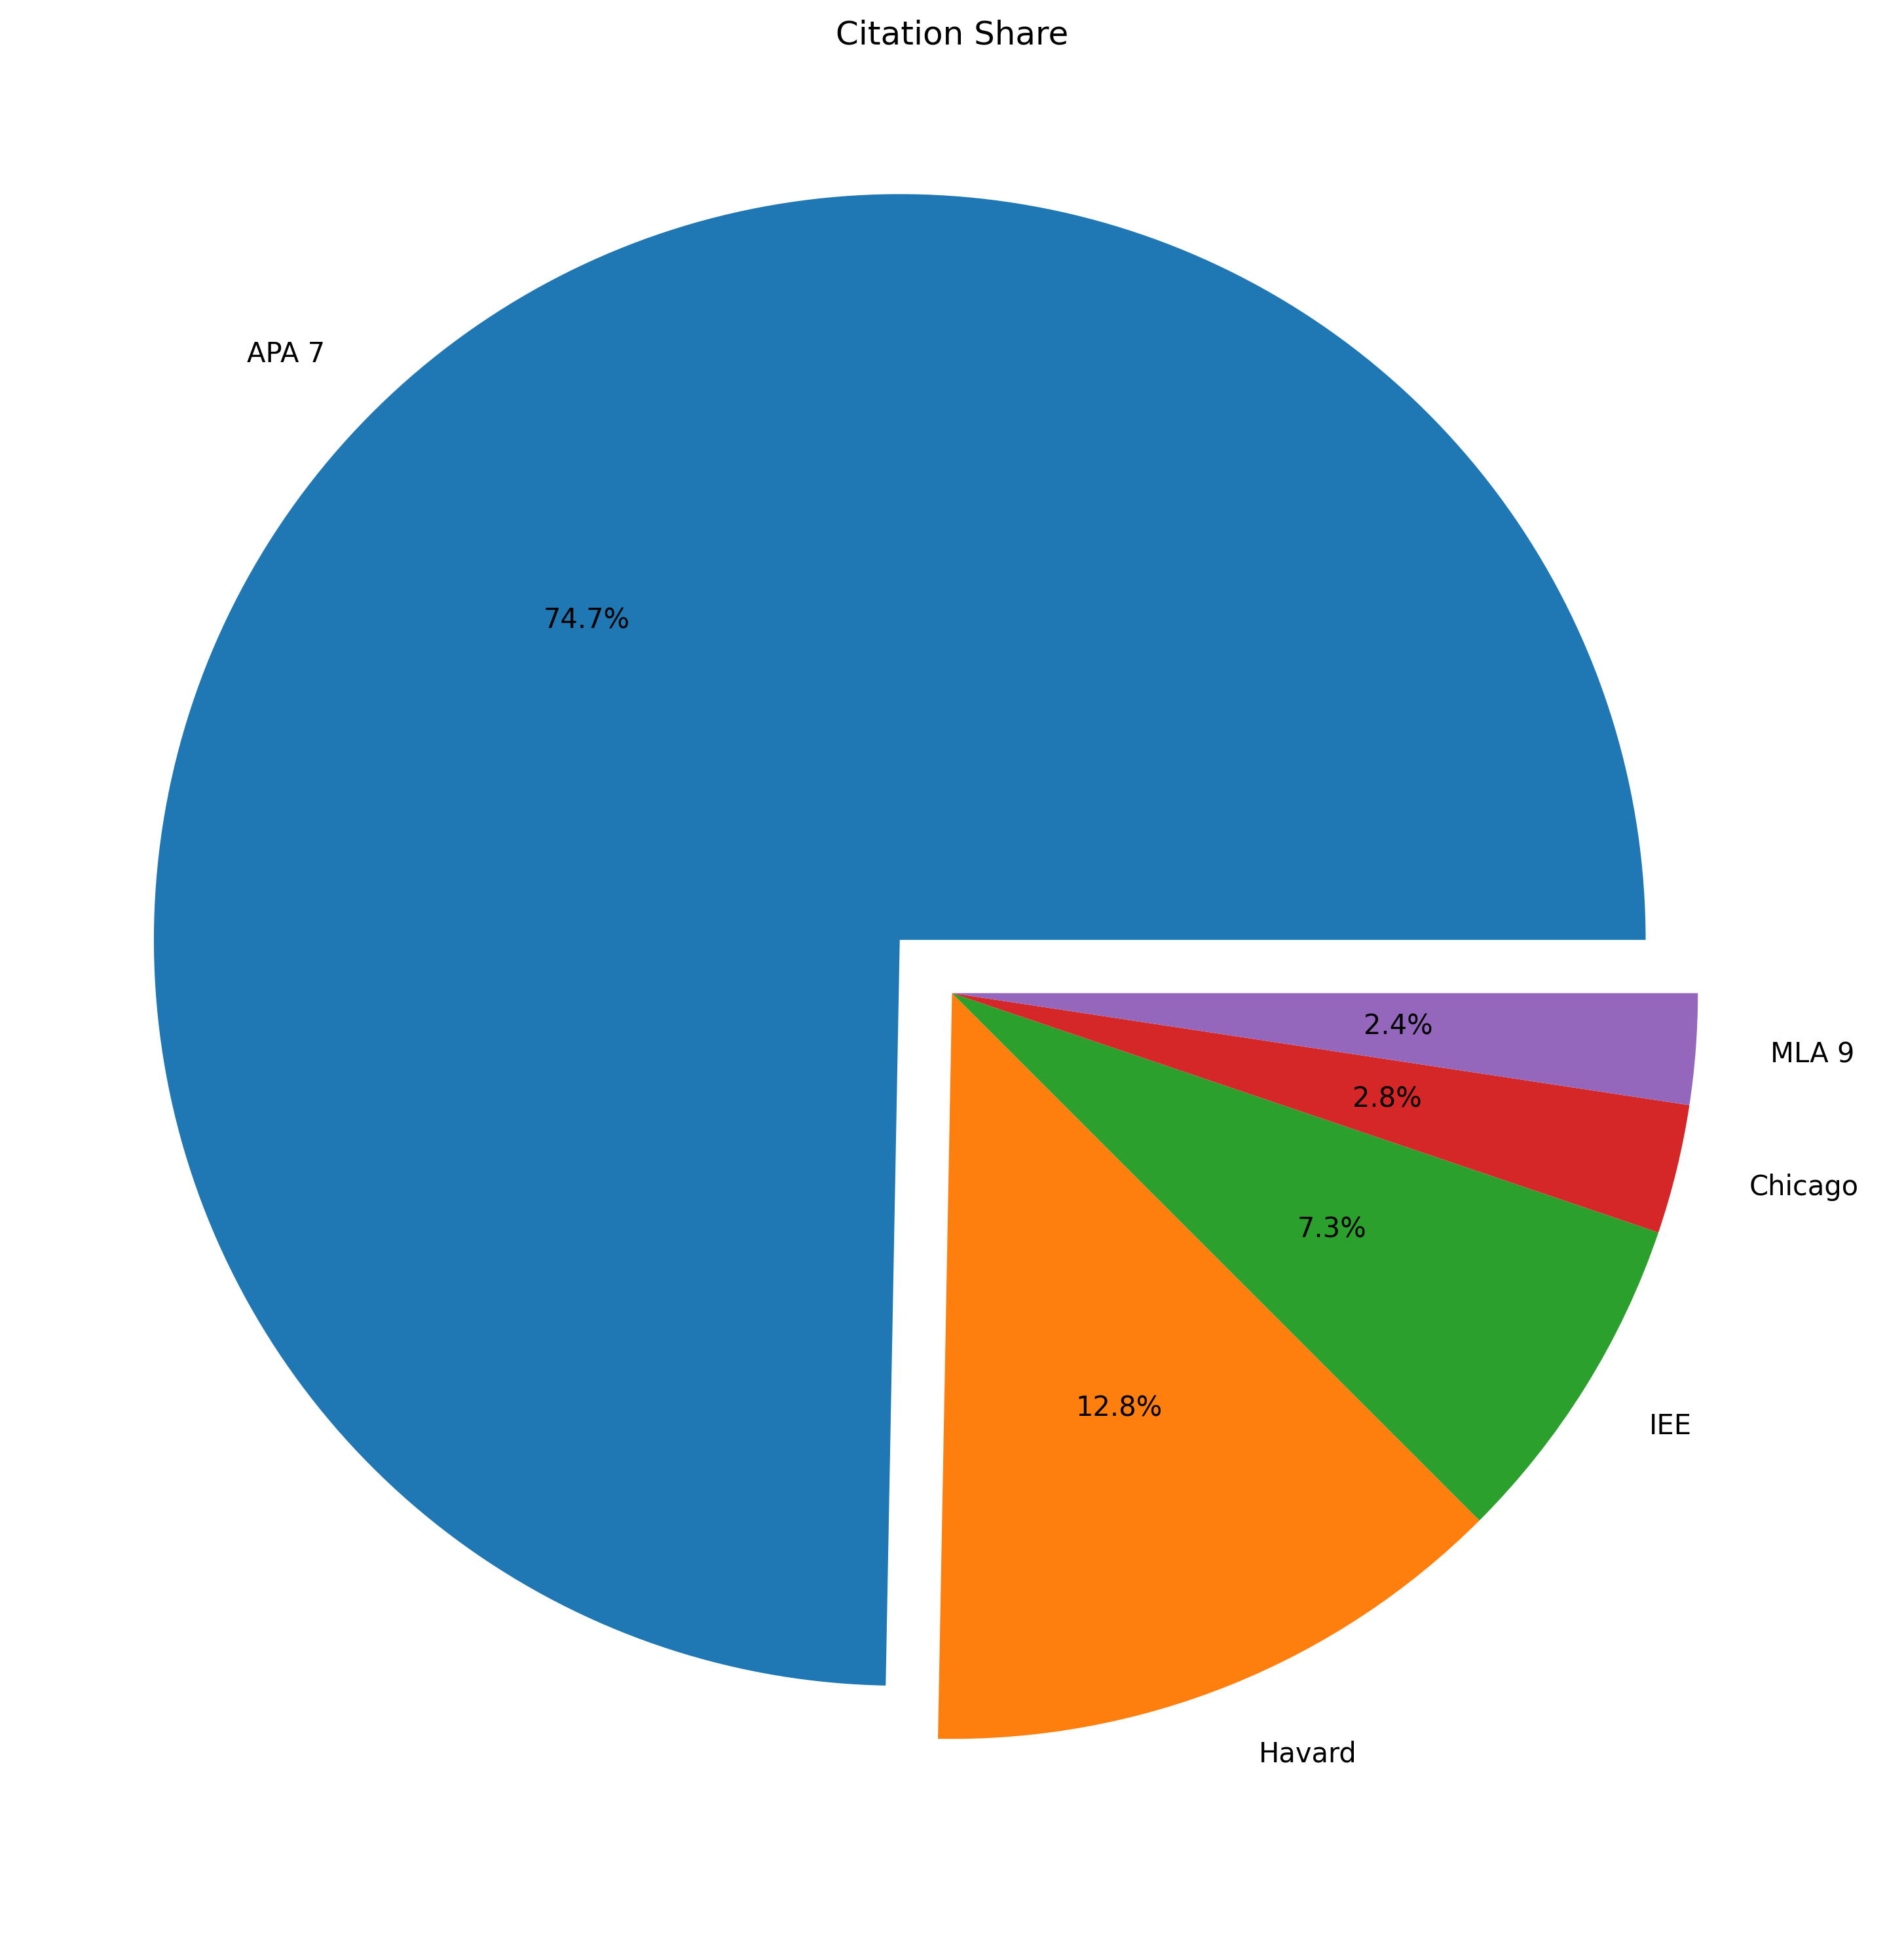

In [258]:
#Pie chart 
lables = ["APA 7","Havard","IEE","Chicago","MLA 9"]
colors = ["orange","green","grey","teal","blue"]
explode = (0.1,0,0,0,0)
plt.figure(figsize=(12,10),dpi=300)
plt.pie(citation_share,labels=lables,autopct='%1.1f%%',explode=explode)
plt.title("Citation Share")
plt.tight_layout()
plt.show()

In [220]:
#AI autonomy 

df["ai_autonomy"].value_counts()

ai_autonomy
Human-in-the-loop    616
Autonomous            55
Name: count, dtype: int64

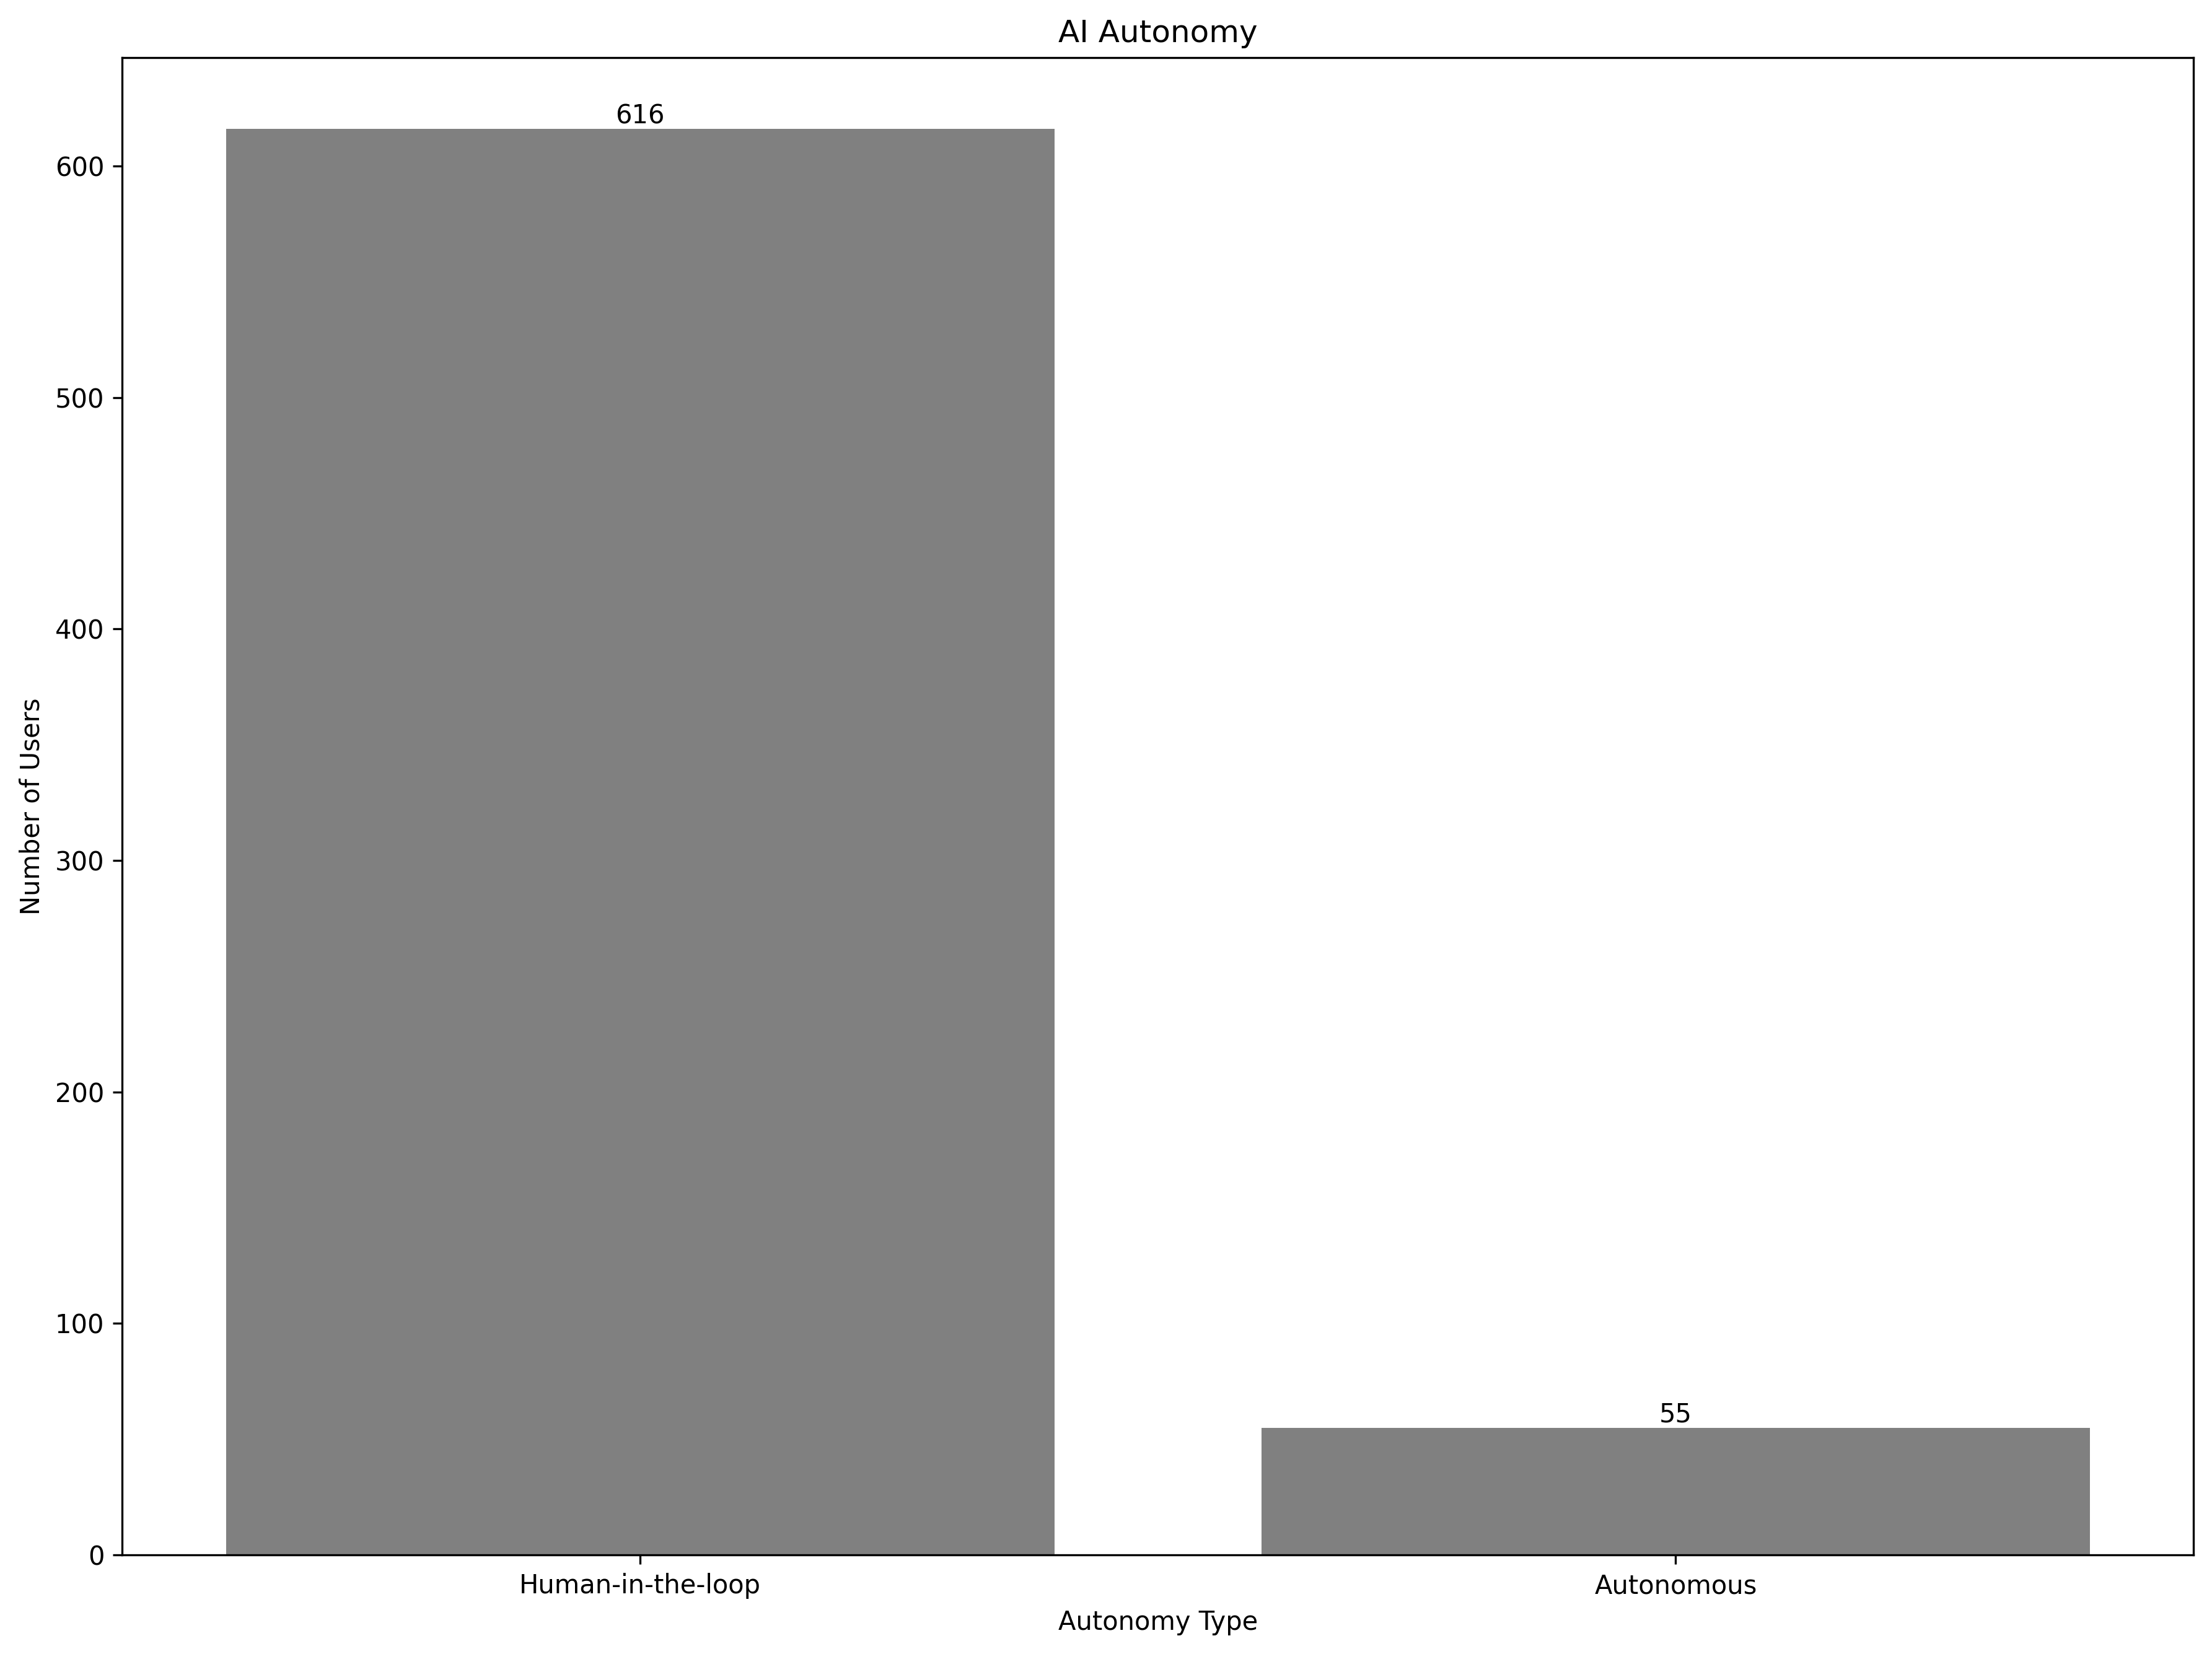

In [221]:
plt.figure(figsize=(12,9),dpi=300)
ax = sns.countplot(data= df ,x="ai_autonomy",color="gray")
plt.title("AI Autonomy")
plt.xlabel("Autonomy Type")
plt.ylabel("Number of Users")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

In [222]:
df["google_signup"] = df["google_id"].notna()

In [223]:
df["google_signup"].value_counts(normalize=True).mul(100)

google_signup
True     99.850969
False     0.149031
Name: proportion, dtype: float64

In [224]:
df["subscription_status"].value_counts()

subscription_status
inactive    669
active        2
Name: count, dtype: int64

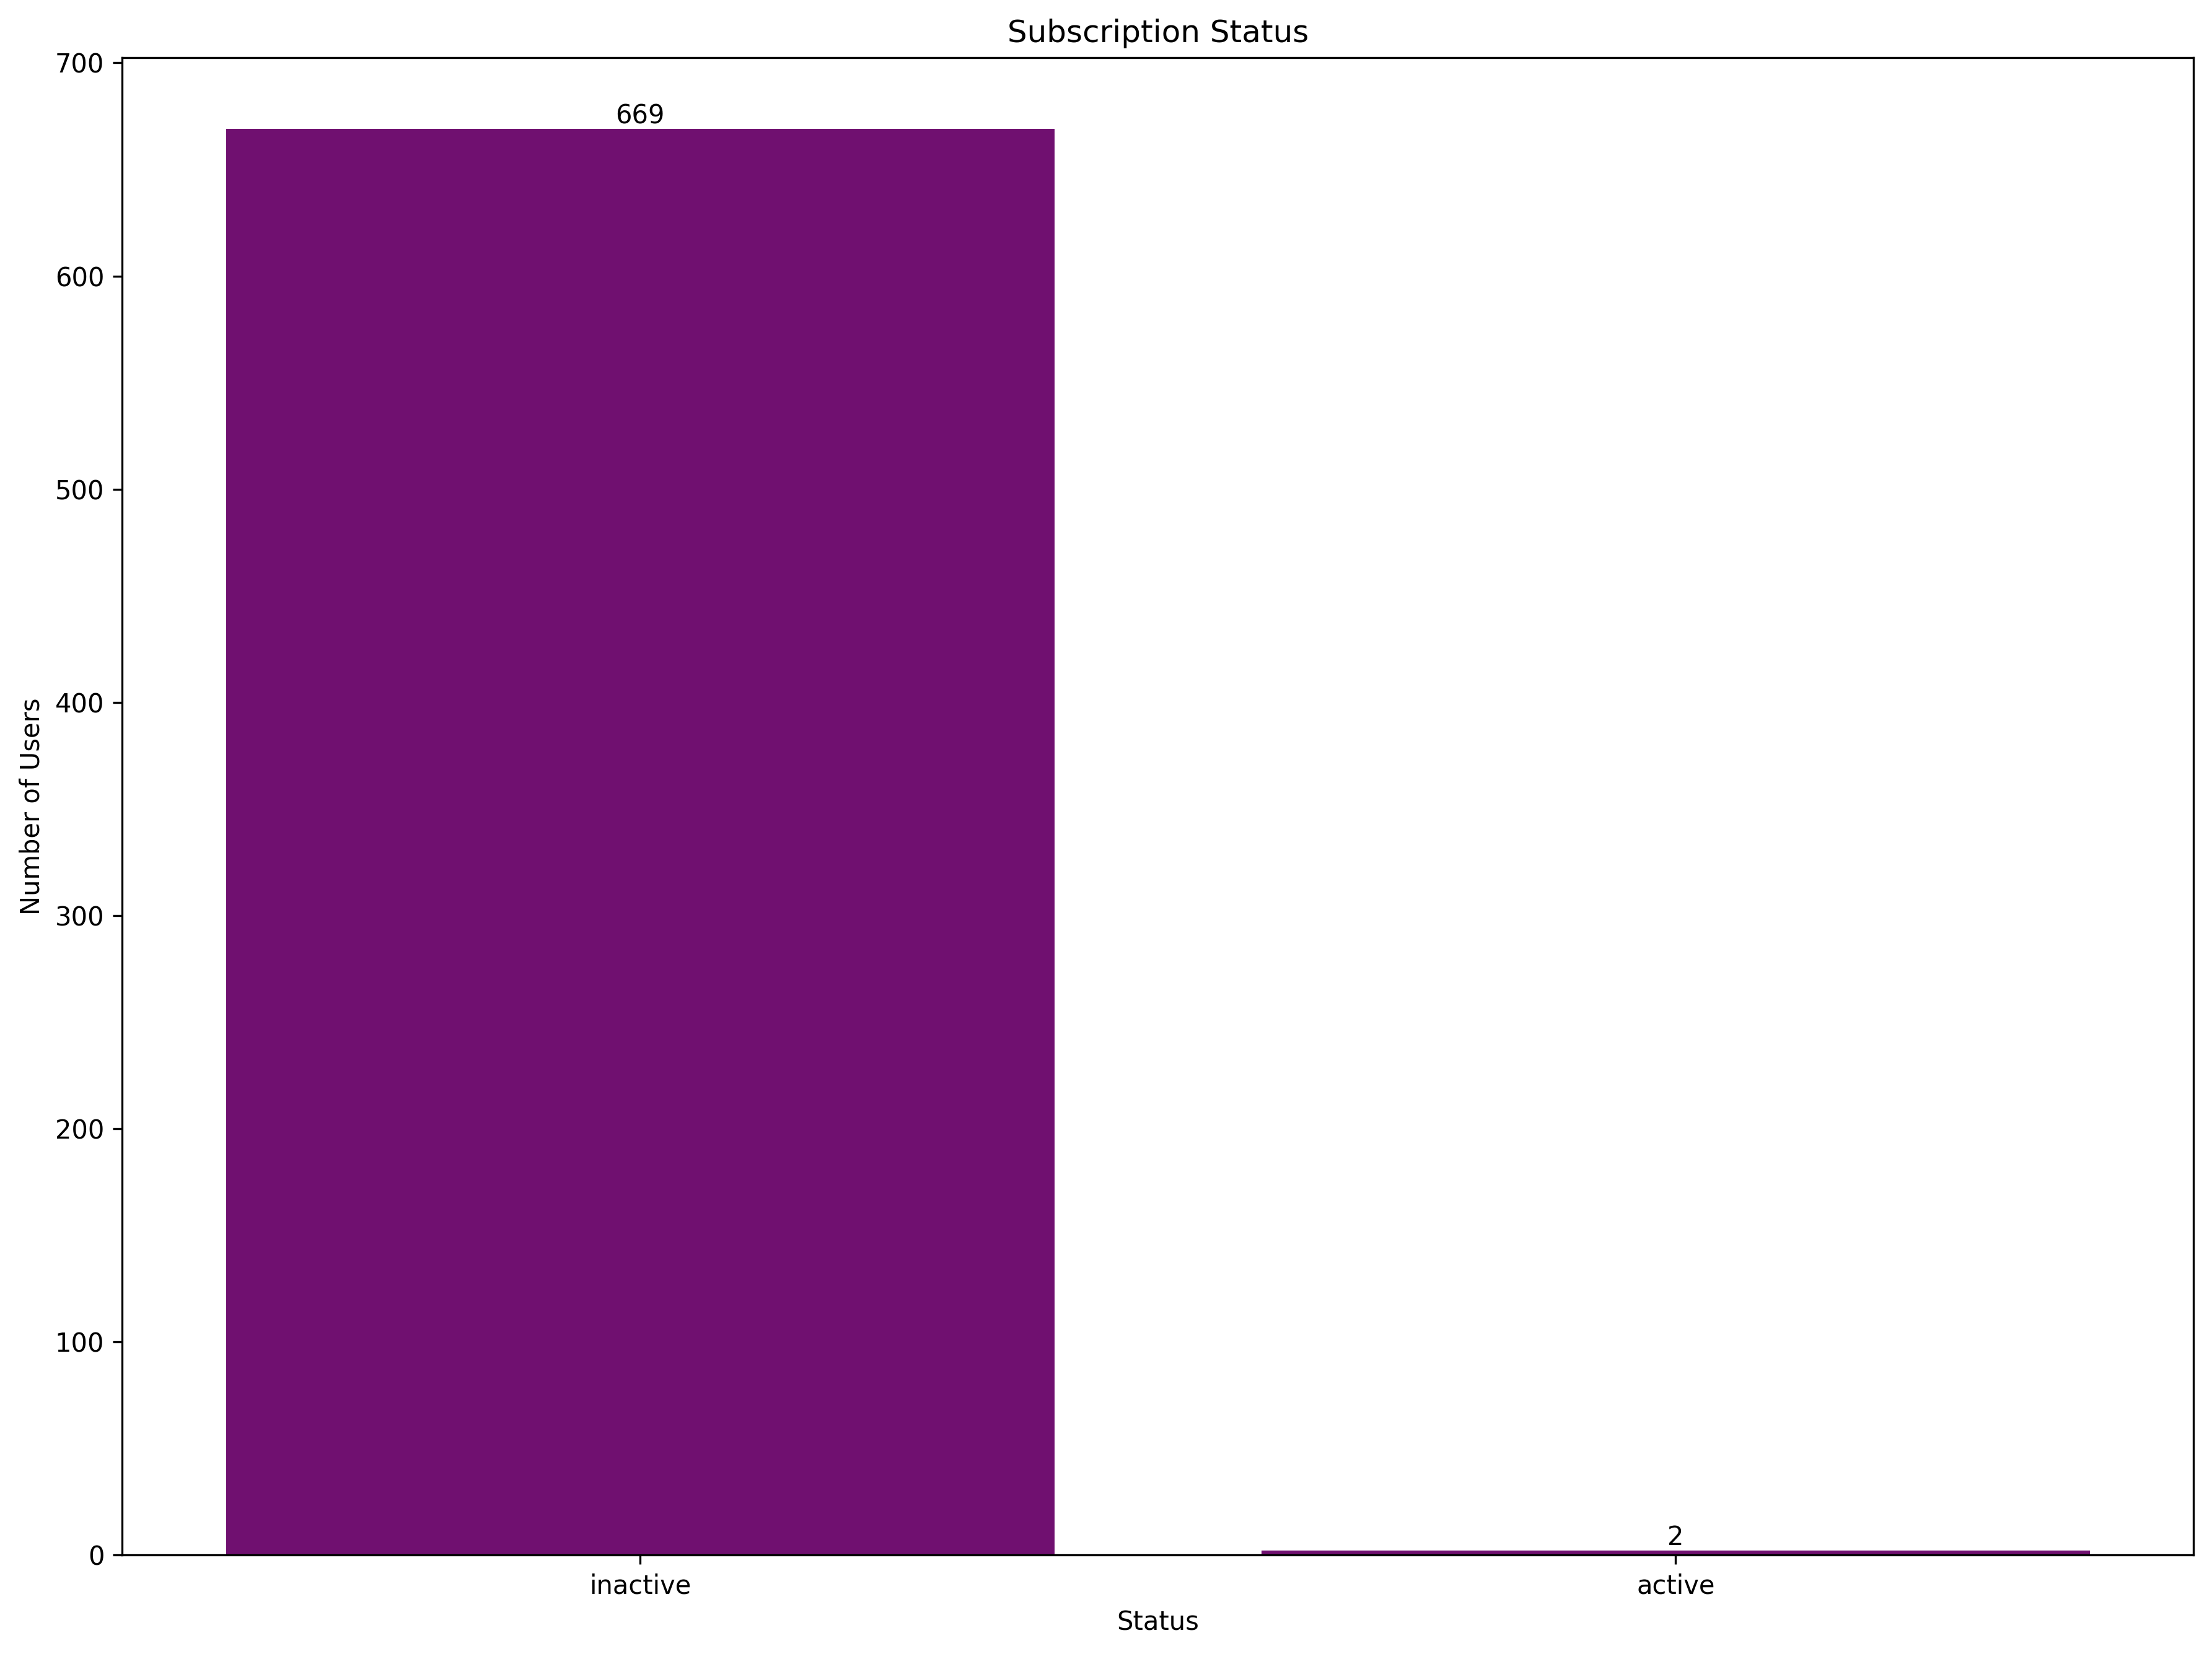

In [232]:
plt.figure(figsize=(12,9),dpi=300)
ax = sns.countplot(data= df ,x="subscription_status",color="purple")
plt.title("Subscription Status")
plt.xlabel("Status")
plt.ylabel("Number of Users")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()